In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_15m_raw.csv", delimiter=";", skiprows=0)

df.head()

,Unnamed: 0,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,taker_buy_quote,ignore,symbol,interval
0,0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,8.576108e+05,0,BTCUSDT,15m
1,1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,6.422812e+05,0,BTCUSDT,15m
2,2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,5.900347e+05,0,BTCUSDT,15m
3,3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,1.000614e+06,0,BTCUSDT,15m
4,4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,4.618369e+05,0,BTCUSDT,15m


In [7]:
df["open_time"] = pd.to_datetime(df["open_time"], format="mixed", utc=True)
df["close_time"] = pd.to_datetime(df["close_time"], format="mixed", utc=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281131 entries, 0 to 281130
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   Unnamed: 0          281131 non-null  int64              
 1   open_time           281131 non-null  datetime64[ns, UTC]
 2   open                281131 non-null  float64            
 3   high                281131 non-null  float64            
 4   low                 281131 non-null  float64            
 5   close               281131 non-null  float64            
 6   volume              281131 non-null  float64            
 7   close_time          281131 non-null  datetime64[ns, UTC]
 8   quote_asset_volume  281131 non-null  float64            
 9   n_trades            281131 non-null  int64              
 10  taker_buy_base      281131 non-null  float64            
 11  taker_buy_quote     281131 non-null  float64            
 12  ignore          

# Estadisticos descriptivos

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,281131.0,1.405650e+05,8.115567e+04,0.00,7.028250e+04,1.405650e+05,2.108475e+05,2.811300e+05
open,281131.0,3.750107e+04,3.233465e+04,3166.11,9.461675e+03,2.748601e+04,5.768957e+04,1.260112e+05
high,281131.0,3.757441e+04,3.238176e+04,3174.78,9.485005e+03,2.753264e+04,5.781750e+04,1.261996e+05
low,281131.0,3.742532e+04,3.228644e+04,3156.26,9.440000e+03,2.743564e+04,5.754981e+04,1.256480e+05
close,281131.0,3.750134e+04,3.233478e+04,3167.07,9.461585e+03,2.748717e+04,5.768972e+04,1.260112e+05
volume,281131.0,6.784796e+02,1.081140e+03,0.00,1.895409e+02,3.488952e+02,6.994438e+02,4.037141e+04
quote_asset_volume,281131.0,1.923880e+07,2.894299e+07,0.00,3.609792e+06,9.813174e+06,2.348509e+07,1.086850e+09
n_trades,281131.0,2.048814e+04,2.901765e+04,0.00,4.437000e+03,1.027600e+04,2.395100e+04,1.754730e+06
taker_buy_base,281131.0,3.369323e+02,5.394826e+02,0.00,9.262793e+01,1.739453e+02,3.478170e+02,1.992562e+04
taker_buy_quote,281131.0,9.498805e+06,1.452241e+07,0.00,1.745557e+06,4.680081e+06,1.156502e+07,5.619115e+08


# Precio de cierre

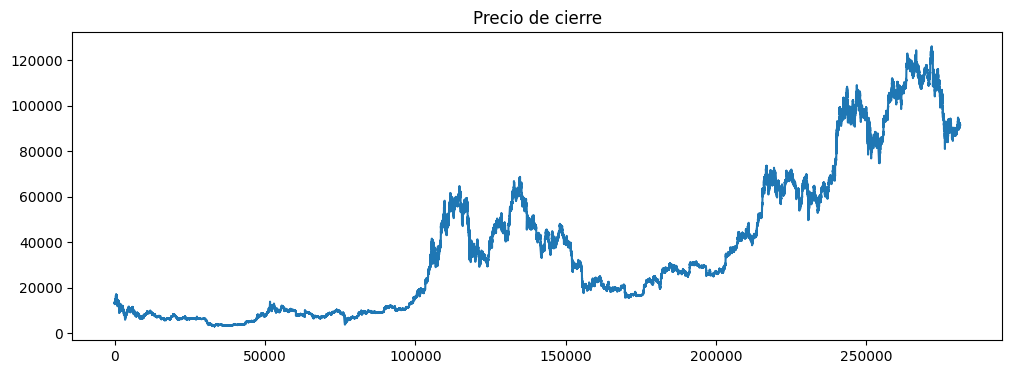

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["close"])
plt.title("Precio de cierre")
plt.show()


# Precio Volumen

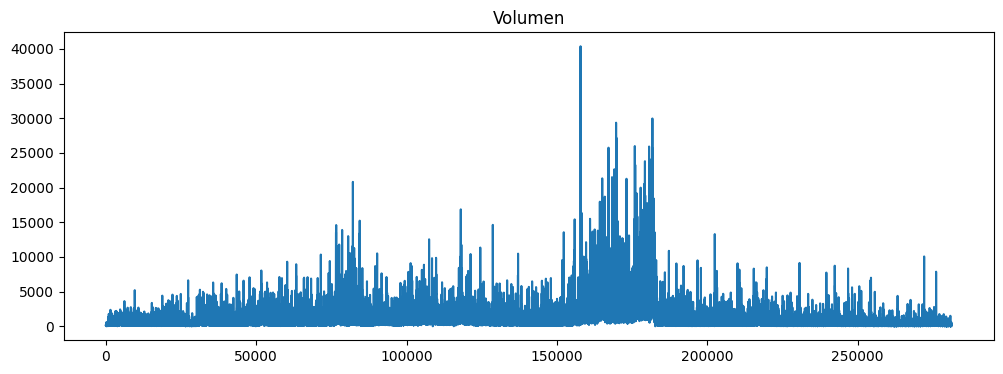

In [11]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["volume"])
plt.title("Volumen")
plt.show()

# Retornos logaritmicos

In [12]:
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Volatilidad rolling

In [13]:
df["volatility_20"] = df["log_return"].rolling(20).std()

# Rango intraperiodo

In [14]:
df["range_hl"] = (df["high"] - df["low"]) / df["open"]

# Intensidad de trades

In [15]:
df["trades_per_volume"] = df["n_trades"] / df["volume"]

# Presión de compra

In [16]:
df["buy_ratio"] = df["taker_buy_base"] / df["volume"]

# Distribuciones (detección visual de outliers)

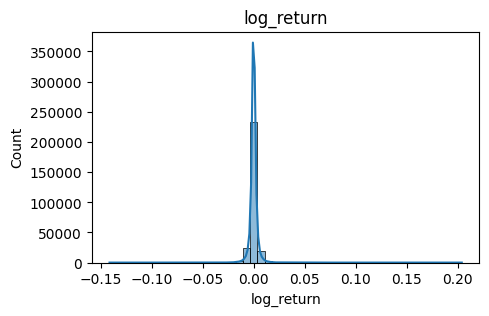

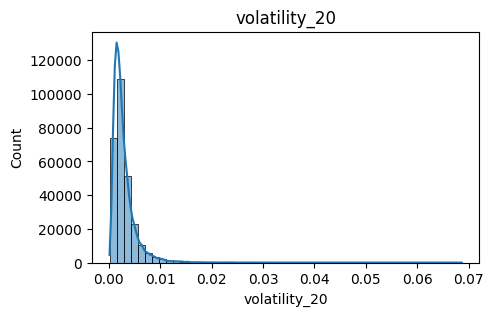

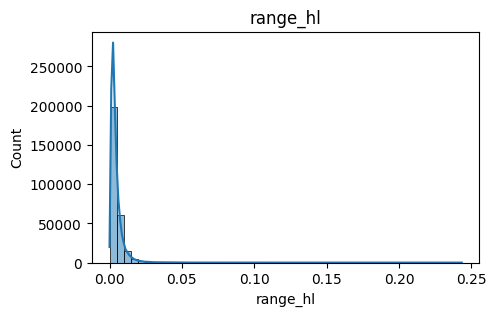

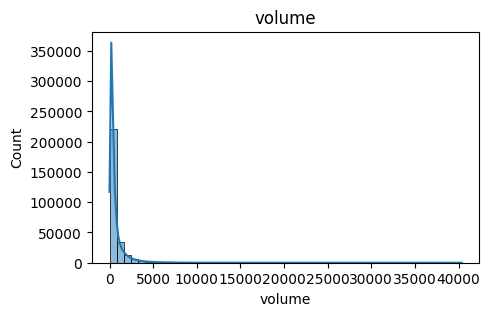

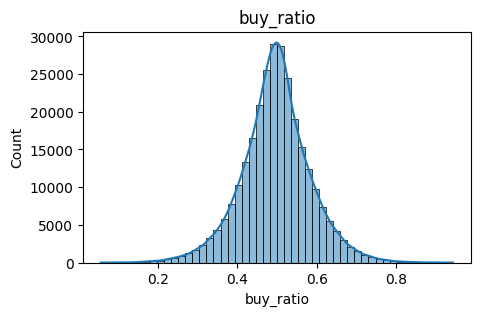

In [22]:
features = ["log_return", "volatility_20", "range_hl", "volume", "buy_ratio"]

for col in features:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(col)
    plt.show()


# Boxplots

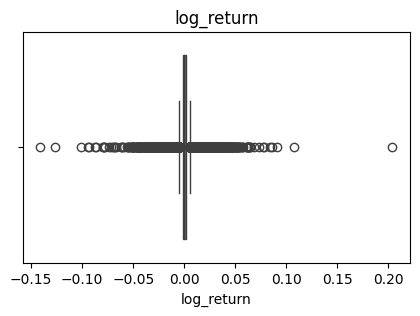

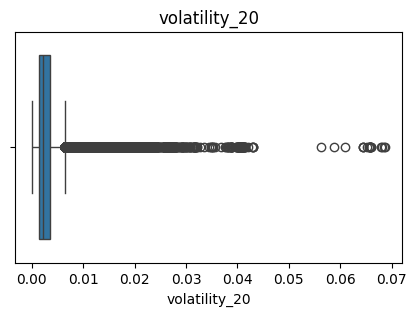

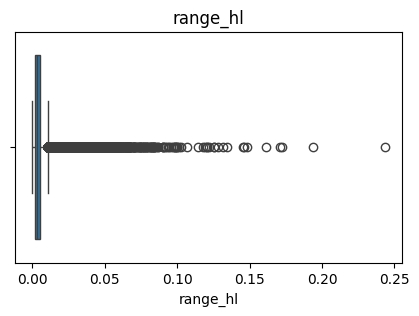

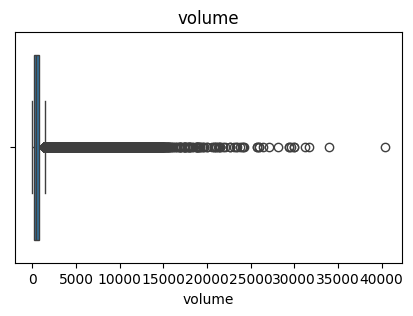

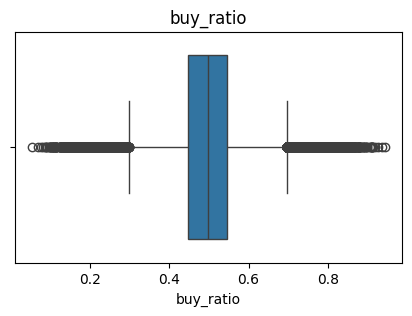

In [23]:
for col in features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


# Correlaciones (multivariado)

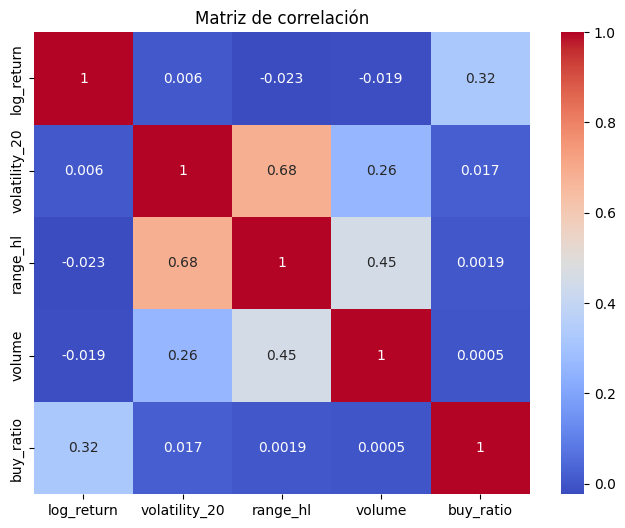

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


# criterio del Z-score

In [ ]:
df["z_return"] = (df["log_return"] - df["log_return"].mean()) / df["log_return"].std()

df["anomaly_simple"] = np.abs(df["z_return"]) > 3
# Marca como anomalía cualquier observación que esté a más de ±3σ del comportamiento típico.

In [26]:
df[df["anomaly_simple"]][["close", "log_return"]].head()

,close,log_return
7,13203.06,-0.017787
8,13387.00,0.013835
9,13225.00,-0.012175
25,13687.76,0.011421
34,13434.71,-0.014644
